In [62]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [63]:
checkpoint = "bert-base-uncased"
task_name  = "stsb"

# 1. Loading our mrpc part of the GLUE dataset

In [64]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

In [65]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [66]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 5749
})

In [67]:
from datasets import DatasetDict

In [68]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [69]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})

In [70]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'A plane is taking off.',
 'sentence2': 'An air plane is taking off.',
 'label': 5.0,
 'idx': 0}

In [71]:
raw_train_dataset[5]['sentence1']

'Some men are fighting.'

In [72]:
raw_train_dataset[5]['sentence2']

'Two men are fighting.'

In [73]:
raw_train_dataset[5]['idx']

5

In [74]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': Value('float32'),
 'idx': Value('int32')}

# 2. Preprocess

In [75]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1379
    })
})

# 3. Preparing for Training

In [76]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [77]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [78]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [79]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 66]),
 'token_type_ids': torch.Size([32, 66]),
 'attention_mask': torch.Size([32, 66])}

# 4. Loading model

In [80]:
import sys
sys.path.insert(0, '../')

In [81]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [82]:
num_labels = 1

In [83]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [84]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [85]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(4.9161, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [86]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    problem_type="regression",
    # id2label=id2label,
    # label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [87]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [88]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(10.6868, grad_fn=<MseLossBackward0>) torch.Size([32, 1])


In [89]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [90]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [91]:
from train_eval_func import eval_loop

In [92]:
eval_loop(teacher_model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

In [93]:
import torch.nn as nn

In [94]:
len(model.bert.encoder.layer)

12

In [95]:
model.bert.encoder.layer = model.bert.encoder.layer[:6]

In [96]:
len(model.bert.encoder.layer)

6

In [97]:
load_path = './weights/top/layer-6-stsb.pt'
best_weight = torch.load(load_path, map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [98]:
eval_loop(teacher_model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

# 5. Similarity Check

In [99]:
from CKA import CKAEvaluator

cka_eval = CKAEvaluator(device)

In [100]:
cls_reps_similarity = cka_eval.pairwise(
    model, 
    train_dataloader, 
    device, 
    only_cls_token=True, 
    max_iter=130
)
stats = cka_eval.similarity_stats(cls_reps_similarity)

print("  Similarity Stats:")
print(f"    Average: {stats['average']:.6f}")
print(f"    Highest: {stats['max']:.6f}")
print(f"    Lowest:  {stats['min']:.6f}")

CKA Evaluation: 100%|██████████| 130/130 [00:03<00:00, 33.35it/s]

  Similarity Stats:
    Average: 0.608717
    Highest: 0.692871
    Lowest:  0.370144


In [101]:
stats

{'average': 0.6087169051170349,
 'max': 0.6928707361221313,
 'argmax': 1,
 'min': 0.3701440989971161,
 'argmin': 2,
 'adj_similarities': [0.6657245, 0.69287074, 0.3701441, 0.6533685, 0.6614769]}

In [102]:
import matplotlib.pyplot as plt
import seaborn as sn

Text(50.722222222222214, 0.5, 'Layer')

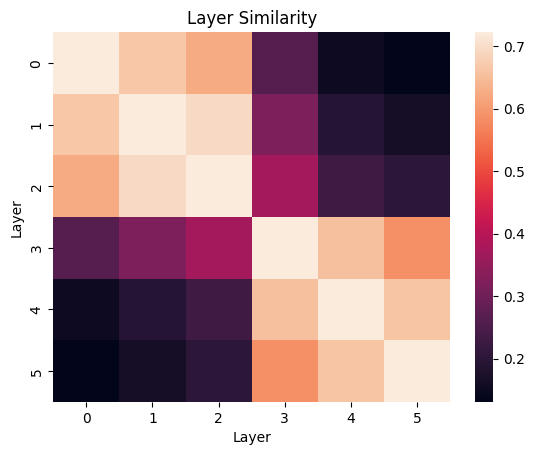

In [103]:
title = "Layer Similarity"
plt.title(title)
sn.heatmap(data = cls_reps_similarity)
plt.xlabel("Layer")
plt.ylabel("Layer")

In [104]:
from structure_prune_helper import compute_importance_scores

In [105]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks

In [106]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [107]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

Computing importance (heads + FFN): 100%|██████████| 180/180 [00:09<00:00, 19.93it/s]


In [108]:
head_importance

[tensor([3.0703e-06, 3.4368e-06, 1.6488e-06, 2.7537e-06, 2.4553e-06, 3.1237e-06,
         1.8403e-06, 1.8698e-06, 5.3151e-06, 2.4086e-06, 2.1905e-06, 1.9198e-06],
        device='cuda:1'),
 tensor([1.4920e-06, 2.6977e-06, 1.8741e-06, 1.4839e-06, 2.8328e-06, 1.3202e-06,
         1.5759e-06, 5.7333e-06, 3.4866e-06, 2.3979e-06, 1.8122e-06, 6.9312e-06],
        device='cuda:1'),
 tensor([2.4423e-06, 2.0398e-06, 4.6538e-06, 7.5580e-06, 1.3993e-06, 3.2408e-06,
         1.1420e-05, 4.9175e-06, 1.2507e-06, 2.3867e-06, 7.9081e-06, 2.6882e-06],
        device='cuda:1'),
 tensor([4.2367e-05, 5.1621e-06, 2.3622e-06, 6.9211e-06, 4.1408e-06, 1.7684e-06,
         3.2819e-06, 1.0310e-05, 2.9341e-06, 1.5823e-06, 1.6956e-05, 2.1646e-06],
        device='cuda:1'),
 tensor([2.3470e-06, 1.9486e-05, 7.6287e-06, 3.6661e-06, 5.0207e-06, 4.8199e-06,
         1.5856e-06, 6.6222e-06, 3.0880e-06, 4.8851e-06, 1.0288e-05, 2.3906e-06],
        device='cuda:1'),
 tensor([8.6833e-06, 9.9525e-07, 9.7883e-06, 1.6942e-05

In [109]:
import matplotlib.pyplot as plt
import torch

# [6, 12]
head_scores = torch.stack(head_importance).cpu()

# Sum all heads inside each layer
layer_scores = head_scores.sum(dim=1)

print(layer_scores.shape)  # [6]
print(layer_scores)

torch.Size([6])
tensor([3.2033e-05, 3.3638e-05, 5.1905e-05, 9.9950e-05, 7.1827e-05, 1.1998e-04])


In [110]:
normalized_scores = (
    (layer_scores - layer_scores.min())
    / (layer_scores.max() - layer_scores.min())
)

In [111]:
normalized_scores

tensor([0.0000, 0.0183, 0.2260, 0.7723, 0.4525, 1.0000])

In [113]:
int(torch.min(normalized_scores))

0

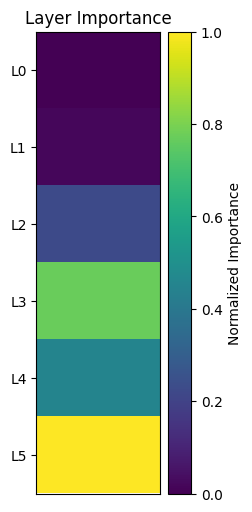

In [50]:
plt.figure(figsize=(2, 6))

im = plt.imshow(
    normalized_scores.unsqueeze(1),
    aspect='auto',
    vmin=0,
    vmax=1
)

plt.colorbar(im, label='Normalized Importance')

plt.yticks(range(6), [f"L{i}" for i in range(6)])
plt.xticks([])

plt.title("Layer Importance")

plt.show()

# 6. Merge Most Similar

In [51]:
eval_loop(teacher_model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.900084701022039, 'spearmanr': 0.8962584593578651}

In [52]:
from structure_prune_helper import compute_importance_scores, register_importance_masks, remove_importance_masks
from layer_merge_helper import merge_mha, merge_ff, reorder_merged_layer_heads, reorder_merged_layer_neurons

In [53]:
register_importance_masks(model, device, register_heads=True, register_ffn=True)

  Layer 0: Registered masks (12 heads, 3072 neurons)
  Layer 1: Registered masks (12 heads, 3072 neurons)
  Layer 2: Registered masks (12 heads, 3072 neurons)
  Layer 3: Registered masks (12 heads, 3072 neurons)
  Layer 4: Registered masks (12 heads, 3072 neurons)
  Layer 5: Registered masks (12 heads, 3072 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [54]:
head_importance, neuron_importance = compute_importance_scores(model, train_dataloader, device, compute_heads=True, compute_ffn=True)

Computing importance (heads + FFN): 100%|██████████| 180/180 [00:08<00:00, 20.43it/s]


In [55]:
merge_layer = 0

In [56]:
head_imp1, indices1 = torch.sort(head_importance[merge_layer], descending=True)
head_imp2, indices2 = torch.sort(head_importance[merge_layer+1], descending=True)

neuron_imp1, indices1 = torch.sort(neuron_importance[merge_layer], descending=True)        
neuron_imp2, indices1 = torch.sort(neuron_importance[merge_layer+1], descending=True)

In [57]:
merge_mha(model, model.bert.encoder.layer[merge_layer], model.bert.encoder.layer[merge_layer+1], head_imp1, head_imp2, device, 4)
merge_ff(model, model.bert.encoder.layer[merge_layer], model.bert.encoder.layer[merge_layer+1], neuron_imp1, neuron_imp2, device, extra_neurons=1024)
    
del model.bert.encoder.layer[merge_layer]

9 7
1871 2225


In [58]:
model.bert.encoder.layer = model.bert.encoder.layer[1:]

In [59]:
model.bert.encoder.layer

ModuleList(
  (0-3): 4 x BertLayer(
    (attention): BertAttention(
      (self): BertSelfAttention(
        (query): Linear(in_features=768, out_features=768, bias=True)
        (key): Linear(in_features=768, out_features=768, bias=True)
        (value): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (output): BertSelfOutput(
        (dense): Linear(in_features=768, out_features=768, bias=True)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (intermediate): BertIntermediate(
      (dense): Linear(in_features=768, out_features=3072, bias=True)
      (intermediate_act_fn): GELUActivation()
    )
    (output): BertOutput(
      (dense): Linear(in_features=3072, out_features=768, bias=True)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
)

In [58]:
eval_loop(model, val_dataloader, task_name, device, regression=True)[0]

{'pearson': 0.8670394321073294, 'spearmanr': 0.8640157574201901}

In [59]:
from torch.optim import AdamW
from train_eval_func import train
from train_eval_func import set_lr_scheduler

In [60]:
optimizer = AdamW(model.parameters(), lr=1e-5)
num_training_steps = 10 * len(train_dataloader)
lr_scheduler = set_lr_scheduler(
    optimizer=optimizer,
    num_training_steps=num_training_steps
)

In [61]:
train_stats = train(
    model,
    train_dataloader,
    val_dataloader,
    task_name,
    device,
    num_epochs=10,
    lr=1e-5,
    patience=3,
    use_early_stopping=True,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    # save_path=temp_save_path,
    display_epoch_iter=True,
    regression=True,
    teacher_model=teacher_model, alpha=0.5, temperature=6
)


Training:   0%|          | 0/1800 [00:00<?, ?it/s]

Knowledge distillation used!


/home/abhinavl/work/Layer_Graft/layer-grafting-publication/drop_layer_strategy/../train_eval_func.py:223: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  10%|▉         | 179/1800 [00:15<02:09, 12.50it/s]


<----------------- Epoch 1 ----------------->
Loss: 0.11, Training Metrics:
  pearson: 0.9488
  spearmanr: 0.9418
Validation Loss: 0.55, Validation Metrics:
  pearson: 0.8722
  spearmanr: 0.8693
Elapsed Time: 17.0699 sec


Training:  20%|██        | 360/1800 [00:33<02:30,  9.56it/s]

...


<----------------- Epoch 8 ----------------->
Loss: 0.04, Training Metrics:
  pearson: 0.9817
  spearmanr: 0.9796
Validation Loss: 0.55, Validation Metrics:
  pearson: 0.8764
  spearmanr: 0.8729
Elapsed Time: 17.7876 sec


Training:  90%|█████████ | 1620/1800 [02:37<00:15, 11.88it/s]


<----------------- Epoch 9 ----------------->
Loss: 0.04, Training Metrics:
  pearson: 0.9820
  spearmanr: 0.9800
Validation Loss: 0.54, Validation Metrics:
  pearson: 0.8769
  spearmanr: 0.8735
Elapsed Time: 17.7546 sec


Training: 100%|██████████| 1800/1800 [02:56<00:00, 10.20it/s]


<----------------- Epoch 10 ----------------->
Loss: 0.04, Training Metrics:
  pearson: 0.9825
  spearmanr: 0.9803
Validation Loss: 0.55, Validation Metrics:
  pearson: 0.8767
  spearmanr: 0.8733
Elapsed Time: 17.7701 sec
>>>>> Early stopping callback <<<<<

Total Training Time: 176.49 sec
